# Glass identification

## Motivation

This dataset drew my attention because of two reasons. First, I was curious why someone wanted to identify the glass based on its use. Second, I saw the Baseline Model performance and thought I certainly can do better with NNC than shown in the picture below. I think especially with SVC and MLP I could receive better results than the presented ones.

The original purpose to collect this data set was motivated by criminological investigations. That is to check the glass at a crime scene and wheter it fits the surroundings or not.

I think identifying glass would be a great way for recycling. In recycling the tricky part is to separate the waste materials. This would make it easier to re-use the materials and save natural resources.

![alt text](Baseline_Models.png)

## Data source and description

The dataset was created by B. German at donated on 8/31/1987. I found this dataset published at https://archive.ics.uci.edu/dataset/42/glass+identification. UC irvine has a lot of datasets that are great for machine learning. They are mostly a bit older, but great for ideas. 

Originally Vina used a rule-based system to classify the different kind of glass. Afterwards machine learning approaches were used to find a better solution. The best results were submitted from Random Forest and Xgboost classifiers. 

One big challenge I see for the NNC is the low number of data points. I hope I can compensate that with a smart MLP design.

The dataset consists of only 214 instances with 9 features each. 8 of these features are chemical elements and are measured in percent in relation to the weight. 
There is also the refractive index. This is a physical parameter which is a measurement for the angle the light bents, when transition from one material to another. <br>
Last, there are 7 different types of glass and its a categorical variable.

The meaning of the numbers for the predicted variables are:

1: building_windows_float_processed <br>
2: building_windows_non_float_processed<br>
3: vehicle_windows_float_processed<br>
4: vehicle_windows_non_float_processed (none in this database)<br>
5: containers<br>
6: tableware<br>
7: headlamps<br>


### Load data

In [99]:
# Load libaries
from ucimlrepo import fetch_ucirepo 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV

from matplotlib.colors import TwoSlopeNorm
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import keras

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [100]:
 # fetch dataset 
glass_identification = fetch_ucirepo(id=42) 
  
# data (as pandas dataframes) 
X = glass_identification.data.features 
y = glass_identification.data.targets 


## EDA

At first, I want to familiarize with the data set and look at statistical values.

In [101]:
# variable information 
print(glass_identification.variables) 

             name     role         type demographic       description  \
0       Id_number       ID      Integer        None              None   
1              RI  Feature   Continuous        None  refractive index   
2              Na  Feature   Continuous        None            Sodium   
3              Mg  Feature   Continuous        None         Magnesium   
4              Al  Feature   Continuous        None          Aluminum   
5              Si  Feature   Continuous        None           Silicon   
6               K  Feature   Continuous        None         Potassium   
7              Ca  Feature   Continuous        None           Calcium   
8              Ba  Feature   Continuous        None            Barium   
9              Fe  Feature   Continuous        None              Iron   
10  Type_of_glass   Target  Categorical        None              None   

                                    units missing_values  
0                                    None             no  
1    

In [102]:
print(X.head())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0


Interesting here is, that the values are Real values, despite the fakt that the are called integer type in the variable information.

In [103]:
print(X.describe())

               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe  
count  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009  
std      1.423153    0.497219    0.097439  
min      5.430000    0.000000    0.000000  
25%      8.240000    0.000000    0.000000  
50%   

Note that barium and ferrum have a very high standard deviation compared to their mean value. <br>
This could indicate that there are outliers in the data set or a high amout of one of these elements could be mapped to a special purpose.

<Axes: >

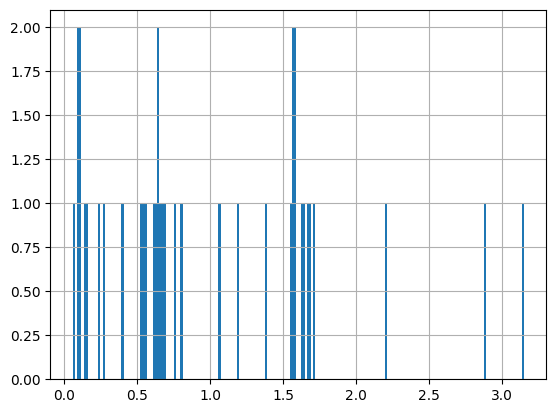

In [104]:
Ba = X.loc[X['Ba'] != 0, 'Ba']
Ba.hist(bins=214)

<Axes: >

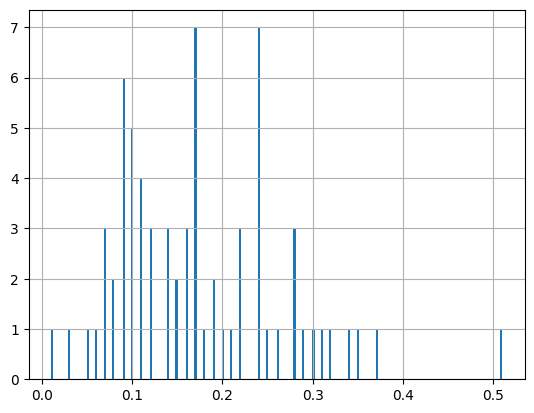

In [105]:
Fe = X.loc[X['Fe'] != 0, 'Fe']
Fe.hist(bins=214)

In these two cases the low mean value is due to the huge number of zero values.

In [106]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
dtypes: float64(9)
memory usage: 15.2 KB


We note that there are no missing values. 

### Feature analysis

#### Correlation matrix

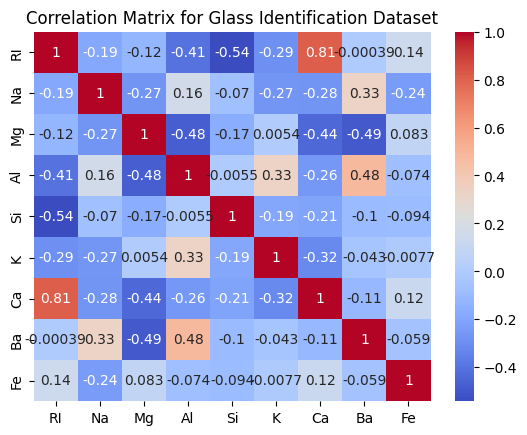

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [107]:
# Create correlation matrix for all features
co_mtx = X.corr()

# Plot the heatmap
sns.heatmap(co_mtx, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Glass Identification Dataset')
plt.show()
plt.figure(figsize=(10, 6))

It seems like RI an CA are correlated. We take a closer look at this.

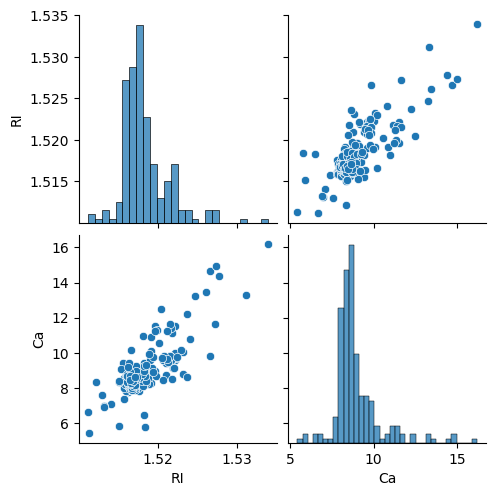

In [108]:
# Create dataset with only the two most correlated features
Corr = X[['RI','Ca']]

# Create pairplot
sns.pairplot(Corr)
plt.show()

It seems that the refractive Index (RI) is directly correlated to the amount of calcium in the glass. At least for our data points.
Therefore, I will drop the column RI and remove it from all further analysis. 

### Target analysis

In [109]:
print(y.head(10))

   Type_of_glass
0              1
1              1
2              1
3              1
4              1
5              1
6              1
7              1
8              1
9              1


It looks like there are a lot of ones. I better take a look at the lable distribution.

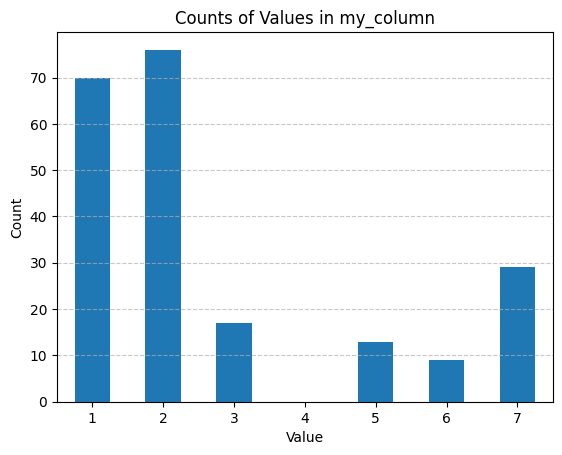

In [110]:
# Count lables and plot bar chart
lbl_count = y['Type_of_glass'].value_counts().reindex(range(1, 8), fill_value=0)
lbl_count.plot(kind='bar')

# Make bar chart looking nice
plt.title('Counts of Values in my_column')
plt.xlabel('Value')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0) 
plt.show()


The labels are not very well distributed and are heavy on the first two categories. Hopefully this will not be a problem

## Model building

In [111]:
# Drop RI from feature set because of high correlation with Ca
x = X.drop(columns=['RI'])

print(x.head()) 

      Na    Mg    Al     Si     K    Ca   Ba   Fe
0  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0
1  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0
2  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0
3  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0
4  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0


### Support Vector Machine (SVM)

At first, I want to see how could a SVC can perform with this data set. I will use a search grid to find the best parameters for this data set and evaluate the results.

In [112]:
# Create SVC
svr = SVC()

# Create grid search parameters
parameters  = [{"C": list(np.logspace(-5, 5, num=11, base=2)) , "gamma": list(np.logspace(-5, 5, num=11, base=2))}]
grid = GridSearchCV(svr, parameters , cv = 3, scoring="accuracy")

# Fit the grid
grid.fit(x, y)

c:\Users\chris\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataC

,estimator,SVC()
,param_grid,"[{'C': [np.float64(0.03125), np.float64(0.0625), ...], 'gamma': [np.float64(0.03125), np.float64(0.0625), ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,np.float64(8.0)


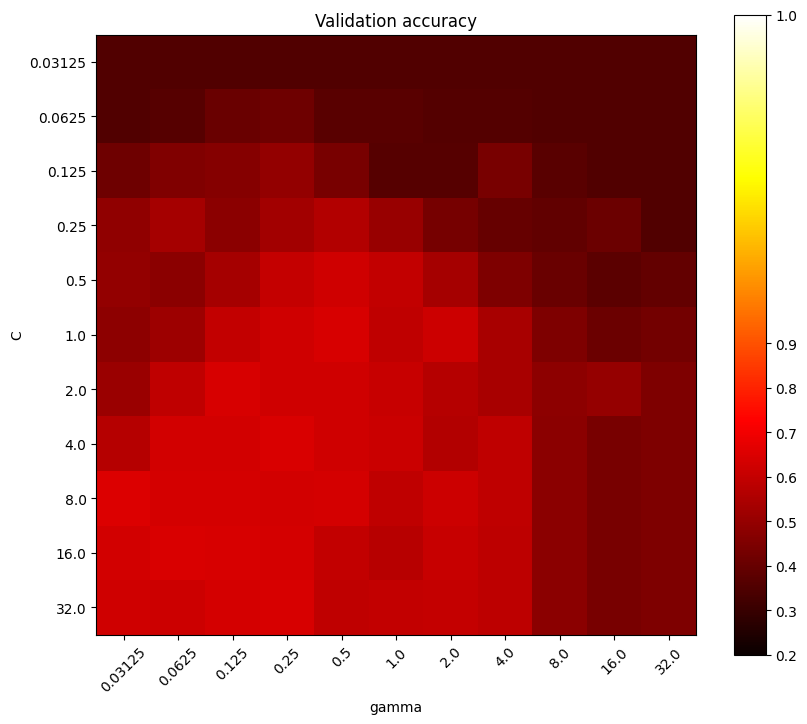

In [113]:
# Print best parameters and best score
scores = [x for x in grid.cv_results_["mean_test_score"]]
scores = np.array(scores).reshape(len(grid.param_grid[0]["C"]), len(grid.param_grid[0]["gamma"]))

# Plot heatmap for best parameters
plt.figure(figsize=(10, 8))
plt.subplots_adjust(left=.2, right=0.95, bottom=0.15, top=0.95)
plt.imshow(scores, interpolation='nearest', cmap=plt.cm.hot,
            norm=TwoSlopeNorm(vmin=0.2, vcenter=0.92, vmax=1))
plt.xlabel('gamma')
plt.ylabel('C')
plt.colorbar()
plt.xticks(np.arange(len(grid.param_grid[0]["gamma"])), grid.param_grid[0]["gamma"], rotation=45)
plt.yticks(np.arange(len(grid.param_grid[0]["C"])), grid.param_grid[0]["C"])
plt.title('Validation accuracy')
plt.show()
    


In [114]:
print(grid.best_params_)
print(grid.best_score_)

{'C': np.float64(8.0), 'gamma': np.float64(0.03125)}
0.6544079290558164


With C = 8.0 and gamma = 0.03125 we get an accuracy of 65.4%.<br>

I still think there is potetial to increase performance, but it is certainly better than the presented solution.

### Multiple Layer Perceptrons (MLP)

Now I want to see how well a MLP can perform with the glass data set.



#### Create train test split

Because there is already so little data I decided to use split 0.3. In this way I have more test data

In [115]:
# Create train test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Subtract one to have labels starting from 0
y_train = y_train - 1
y_test = y_test - 1

# Print the shape to confirm how many input features we have
print(X_train.shape)

(149, 8)


#### Model architecture (Base Model)

At first, I want to create a stable base model from which I can start the hyperparameter tuning. <br>
I start out with a basic two hidden layer model and the standard activation functions.

In [116]:
# Create layers for the MLP
mlp_glass_base = models.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(30, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(30, activation='relu'),
    layers.Dense(7, activation='softmax')  

])

# Define compile parameters
opt = keras.optimizers.SGD(learning_rate=0.0001)
mlp_glass_base.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#### Model training

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.1176 - loss: 14.5747 - val_accuracy: 0.1333 - val_loss: 7.2401
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2353 - loss: 9.3933 - val_accuracy: 0.4000 - val_loss: 4.7690
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2101 - loss: 8.1649 - val_accuracy: 0.4000 - val_loss: 3.5245
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2521 - loss: 7.3712 - val_accuracy: 0.2333 - val_loss: 3.4790
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2773 - loss: 6.5667 - val_accuracy: 0.2333 - val_loss: 3.6801
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2857 - loss: 6.1711 - val_accuracy: 0.2333 - val_loss: 3.4270
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2941 - loss: 5.6136 - val_accuracy: 0.2333 - val_loss: 3.5427
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2437 - loss: 5.8147 - val_accuracy: 0

<function matplotlib.pyplot.show(close=None, block=None)>

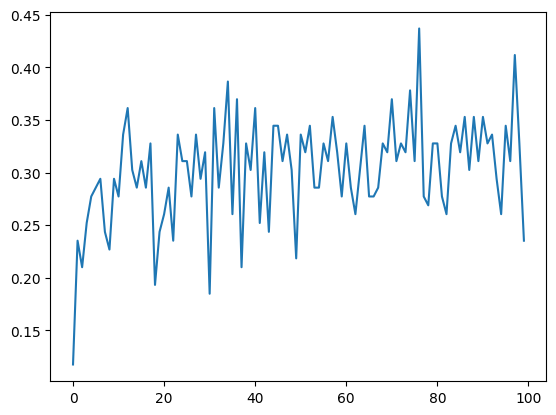

In [117]:
# Train the model
history = mlp_glass_base.fit(X_train, y_train, epochs=100, batch_size=10,validation_split=0.2)

# Evaluate the model
test_loss, test_acc = mlp_glass_base.evaluate(X_test, y_test)
 
# Print Test accuracy and trainings acc
print('Test accuracy:', test_acc)

plt.plot(history.history['accuracy'])
plt.show

The results are already better than in the model from the website, but 30% is by far not good enough. 

### Hyperparameter Tuning

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.2689 - loss: 5.4193 - val_accuracy: 0.4000 - val_loss: 2.8541
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2857 - loss: 3.1314 - val_accuracy: 0.2333 - val_loss: 1.9981
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2941 - loss: 2.2723 - val_accuracy: 0.4000 - val_loss: 1.8185
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2941 - loss: 2.1062 - val_accuracy: 0.3333 - val_loss: 1.7299
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2521 - loss: 1.9629 - val_accuracy: 0.2333 - val_loss: 1.6752
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3025 - loss: 1.7946 - val_accuracy: 0.2333 - val_loss: 1.7530
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3109 - loss: 1.8670 - val_accuracy: 0.2333 - val_loss: 1.7609
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3109 - loss: 1.6514 - val_accu

<function matplotlib.pyplot.show(close=None, block=None)>

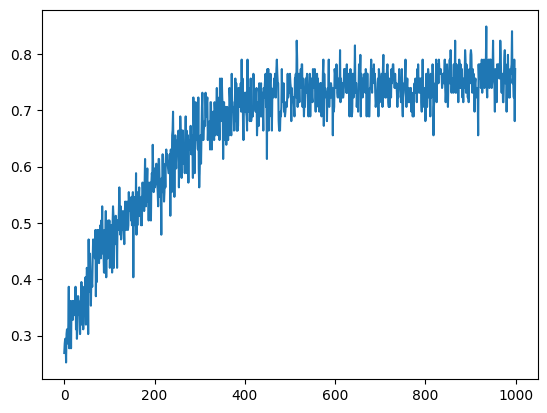

In [118]:
# Create layers for the MLP
mlp_glass = models.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(30, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(30, activation='relu'),
    layers.Dense(7, activation='softmax')  

])

# Define compile parameters
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    decay_rate=0.9)

opt = keras.optimizers.Adam(learning_rate=lr_schedule)
mlp_glass.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = mlp_glass.fit(X_train, y_train, epochs=1000, batch_size=10,validation_split=0.2)

# Evaluate the model
test_loss, test_acc = mlp_glass.evaluate(X_test, y_test)
 
# Print Test accuracy and trainings acc
print('Test accuracy:', test_acc)

plt.plot(history.history['accuracy'])
plt.show

|      Change     |  Eval Accuracy  |   Test Accuracy  | 
| :-------------- | :-------------: |  :-------------: | 
|       Base      |       34.4      |       35.4       |
|  Adam optimizer |       38.7      |       30.8       |
| learning rate 0.00001 |       20.3      |       19.8       |
| add hidden layers |       37.8      |       29.2      |
| Add learning rate scheduler  |     36.1     |      29.2       |
|   Perceptrons 100    |       42.7      |       38.2       |
|   epochs 500    |       76.5      |       64.6       |
|   epochs 1000    |       81.5     |      66.2      |

The best improvement was by using a learning scheduler and increase the number of epochs. I think this really made a big improvement in the model performance. Now this model can keep up with the random forrest classifier.

### Confusion Matix

At last, I want to see how the model performed at the single categories

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


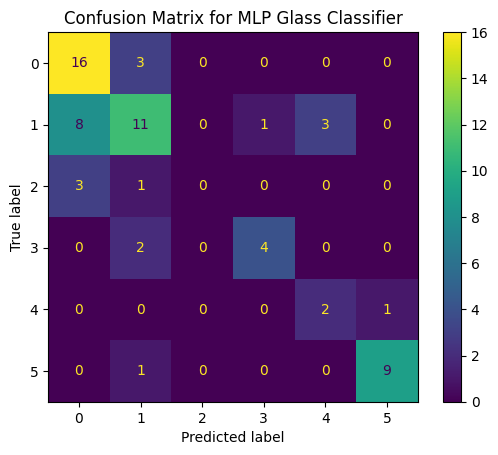

In [119]:
# Get predictions
predictions = mlp_glass.predict(X_test)

# Convert to class labels
pred = np.argmax(predictions, axis=1)
pred = pred + 1

# Prepare true labels for 
y_test_prep = y_test.to_numpy() + 1
y_test_prep = y_test_prep.flatten()


# Create confusion matrix
cm = confusion_matrix(y_test_prep, pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.title("Confusion Matrix for MLP Glass Classifier")
plt.show() 

## Conclusion

The EDA has shown that the categories are not evenly distributed. 
However, the rest of the data was well collected, meaning no missing values etc. 

The SVM received a satisfying accuracy after the first grid search with 65.4%.
Using a more sofisticated way to create test and traing set where the categories are better
distributed and maybe a pipeline for grid search could increase the accuracy even more. 

At first, the MLP did not seem to keep up with the other classifiers. A learning scheduling and the 
increase of the trainings epochs made the break through. 
They were able to reach an accuracy of 66.2% at the test data.<br>

For further improvement I would suggest to use a more advanced loss function and try other activation functions.

A very interesting point is the confusion matrix. It shows that label 1 was confused with label 0 very often. 
I think this is due to the fact that they are both building window, but are differently produced.
It makes perfectly sence that the chemical elements would not necessarily show this difference. 
Maybe this is the reason why the RI was included.

Therefore I would also include the RI and redo the analysis. 
